In [2]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.special as special
from scipy.optimize import curve_fit

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

In [ ]:
## Working distance = 1.61 mm @ 1064 nm
## Effective focal length = 3.126426 mm @ 1064 nm

epsilon0 = 8.8541878188e-12
hbar = 1.055e-34 # (J / Hz) = (kg * m^2 / s)
c = 299792458    # m / s

lam = 1064e-9    # Laser wavelength (m)
k = 2 * np.pi / lam
n1 = n2 = 1      # Refractive indices of the mediums

f = 3.126426e-3  # Focal length (m)
f0 = 1.8         # Fill factor
na = 0.77

theta_max = np.arcsin(na)

In [4]:
r = 83e-9
V = 4/3 * np.pi * r**3

epsilon = 1.4**2   # permittivity of silica sphere
alpha0 = 3 * V * epsilon0 * (epsilon - 1) / (epsilon + 2) # polarizability
alpha  = alpha0 / (1 - 1j * k**3 * alpha0 / (6 * np.pi * epsilon0))  # effective polarizability

In [5]:
## Use Eq. (3.66) of Novotny and Hecht to calculate E field at the lens
## focus
def f_w(theta, f0, theta_max):
    return np.exp(-1 * np.sin(theta)**2 / (f0**2 * np.sin(theta_max)**2))

def I_01(rho, z, k, f0, theta_max):
    tt = np.linspace(1e-3, theta_max, 500)

    f_w_theta = f_w(tt, f0, theta_max)
    j_1_term = special.jv(1, k*rho*np.sin(tt))
    integrand = f_w_theta * np.sqrt(np.cos(tt)) * np.sin(tt)**2 * j_1_term * np.exp(1j * k * z * np.cos(tt))

    return np.trapz(integrand, tt)

def I_00(rho, z, k, f0, theta_max):
    tt = np.linspace(1e-3, theta_max, 500)

    f_w_theta = f_w(tt, f0, theta_max)
    j_0_term = special.jv(0, k*rho*np.sin(tt))
    integrand = f_w_theta * np.sqrt(np.cos(tt)) * np.sin(tt) * (1 + np.cos(tt)) * j_0_term * np.exp(1j * k * z * np.cos(tt))

    return np.trapz(integrand, tt)

def I_02(rho, z, k, f0, theta_max):
    tt = np.linspace(1e-3, theta_max, 500)

    f_w_theta = f_w(tt, f0, theta_max)
    j_2_term = special.jv(2, k*rho*np.sin(tt))
    integrand = f_w_theta * np.sqrt(np.cos(tt)) * np.sin(tt) * (1 - np.cos(tt)) * j_2_term * np.exp(1j * k * z * np.cos(tt))
    
    return np.trapz(integrand, tt)

def E_x(rhorho, zz, psi, k, f, f0, theta_max, n1, n2, E0):
    ret = np.empty((rhorho.size, zz.size), dtype=np.complex128)

    for i, rho in enumerate(rhorho):
        for j, z in enumerate(zz):
            ret[i, j] = (-1j * k * f / 2) * np.sqrt(n1/n2) * E0 * np.exp(-1j * k * f) * (I_00(rho, z, k, f0, theta_max) + I_02(rho, z, k, f0, theta_max) * np.cos(2*psi))
            
    return ret

def E_y(rhorho, zz, psi, k, f, f0, theta_max, n1, n2, E0):
    ret = np.empty((rhorho.size, zz.size), dtype=np.complex128)
    for i, rho in enumerate(rhorho):
        for j, z in enumerate(zz):
            ret[i, j] = (-1j * k * f / 2) * np.sqrt(n1/n2) * E0 * np.exp(-1j * k * f) * (I_02(rho, z, k, f0, theta_max) * np.sin(2*psi))
            
    return ret

def E_z(rhorho, zz, psi, k, f, f0, theta_max, n1, n2, E0):
    ret = np.empty((rhorho.size, zz.size), dtype=np.complex128)
    
    for i, rho in enumerate(rhorho):
        for j, z in enumerate(zz):
            ret[i, j] = (-1j * k * f / 2) * np.sqrt(n1/n2) * E0 * np.exp(-1j * k * f) * (-2j * I_01(rho, z, k, f0, theta_max) * np.cos(psi))
        
    return ret


#### Calculate E field at the focus

In [6]:
e0 = 1

rho = np.linspace(-1e-5, 1e-5, 2500)
zz = np.array([0])
psi = 0

ex_x = E_x(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ey_x = E_y(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ez_x = E_z(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)

In [7]:
rho = np.linspace(-1e-5, 1e-5, 2500)
zz = np.array([0])
psi = np.pi / 2

ex_y = E_x(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ey_y = E_y(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ez_y = E_z(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)

In [8]:
rho = np.array([0])
zz = np.linspace(-1e-5, 1e-5, 1000)
psi = 0

ex_z = E_x(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ey_z = E_y(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)
ez_z = E_z(rho, zz, psi, k, f, f0, theta_max, n1, n2, e0)

In [9]:
rho_plot = np.linspace(-1e-5, 1e-5, 2500)
z_plot = np.linspace(-1e-5, 1e-5, 1000)

e2_x = np.abs(ex_x.T[0])**2 + np.abs(ey_x.T[0])**2 + np.abs(ez_x.T[0])**2
e2_y = np.abs(ex_y.T[0])**2 + np.abs(ey_y.T[0])**2 + np.abs(ez_y.T[0])**2
e2_z = np.abs(ex_z[0])**2 + np.abs(ey_z[0])**2 + np.abs(ez_z[0])**2

#### Fit an effective waist to the calculated E field

In [10]:
def ez_func(zz, e0, z0):
    return e0 / np.sqrt(1 + (zz/z0)**2)

def exy_func(xx, e0, wx):
    return e0 * np.exp(-1 * xx**2 / wx**2)

In [11]:
fit_window_z = np.logical_and(z_plot > -0.532e-6, z_plot < 0.532e-6)

ezmax = np.max(np.sqrt(e2_z[fit_window_z]))
popt, pcov = curve_fit(lambda z, z0: ez_func(z, ezmax, z0), z_plot[fit_window_z], np.sqrt(e2_z[fit_window_z]), p0=[1e-6])

z0 = popt[0]

In [12]:
fit_window_xy = np.logical_and(rho_plot > -0.532e-6, rho_plot < 0.532e-6)

exmax = np.max(np.sqrt(e2_x[fit_window_xy]))
popt, pcov = curve_fit(lambda x, wx: exy_func(x, exmax, wx), rho_plot[fit_window_xy], np.sqrt(e2_x[fit_window_xy]), p0=[0.5e-6])

wx = popt[0]

eymax = np.max(np.sqrt(e2_y[fit_window_xy]))
popt, pcov = curve_fit(lambda y, wy: exy_func(y, eymax, wy), rho_plot[fit_window_xy], np.sqrt(e2_y[fit_window_xy]), p0=[0.5e-6])

wy = popt[0]


Effective beam waists/Rayleigh range: 0.715 (x), 0.591 (y), 1.606 (z) um


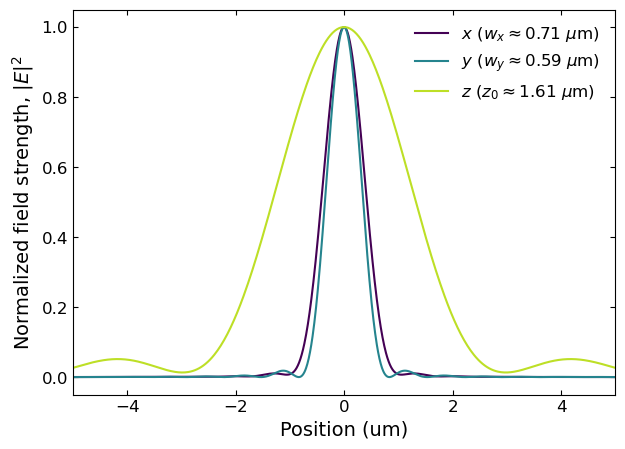

In [13]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.9, 3))

plt.plot(rho_plot/1e-6, e2_x/np.max(e2_x), '-', color=colors[0], label=rf'$x$ ($w_x \approx {wx/1e-6:.2f}$ $\mu$m)')
plt.plot(rho_plot/1e-6, e2_y/np.max(e2_y), '-', color=colors[1], label=rf'$y$ ($w_y \approx {wy/1e-6:.2f}$ $\mu$m)')
plt.plot(z_plot/1e-6, e2_z/np.max(e2_z), '-', color=colors[2], label=rf'$z$ ($z_0 \approx {z0/1e-6:.2f}$ $\mu$m)')

# plt.plot(rho_plot[fit_window_xy]/1e-6, exy_func(rho_plot[fit_window_xy], exmax, wx)**2 / np.max(e2_x), '-', color=colors[0], linewidth=1)
# plt.plot(rho_plot[fit_window_xy]/1e-6, exy_func(rho_plot[fit_window_xy], eymax, wy)**2 / np.max(e2_y), '-', color=colors[1], linewidth=1)
# plt.plot(z_plot[fit_window_z]/1e-6, ez_func(z_plot[fit_window_z], ezmax, z0)**2 / np.max(e2_z), '-', color=colors[2], linewidth=1)

plt.xlim(-5, 5)
plt.legend(frameon=False)
plt.ylabel('Normalized field strength, $|E|^2$')
plt.xlabel('Position (um)')

print(f'Effective beam waists/Rayleigh range: {wx/1e-6:.3f} (x), {wy/1e-6:.3f} (y), {z0/1e-6:.3f} (z) um')
plt.savefig('focal_field.pdf', dpi=300)

In [19]:
p0_beam = 139e-3  # W
e0_beam = np.sqrt(p0_beam * 4 / (c * epsilon0 * np.pi * wx * wy))

alpha_real = np.real(alpha)

kx = alpha_real * e0_beam**2 / (wx**2)
ky = alpha_real * e0_beam**2 / (wy**2)
kz = alpha_real * e0_beam**2 / (2 * z0**2)

m = 2000 * V
omega_x = np.sqrt(kx / m)
omega_y = np.sqrt(ky / m)
omega_z = np.sqrt(kz / m)

print(f'Predicted x frequency: {omega_x / (2 * np.pi):.2f} Hz')
print(f'Predicted y frequency: {omega_y / (2 * np.pi):.2f} Hz')
print(f'Predicted z frequency: {omega_z / (2 * np.pi):.2f} Hz')


Predicted x frequency: 158724.89 Hz
Predicted y frequency: 192133.51 Hz
Predicted z frequency: 49964.63 Hz


In [20]:
# i0 = 2 * p0_beam / (np.pi * z0**2)
i0 = 2 * p0_beam / (np.pi * wx * wy )
# i0 = p0_beam * k**2 * na**2 / (2 * np.pi)
sigma = (8/3) * np.pi * (alpha_real * k**2 / (4 * np.pi * epsilon0))**2

print(f'Power scattered by the sphere: {i0 * sigma / 1e-6:.3f} uW')

Power scattered by the sphere: 40.999 uW


In [15]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3), (E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C